# **Tugas 1 Machine Learning**



Nama: Muhammad Zidan, NIM: 054872864, Prodi: Data Science, UPBJJ: UT Palembang

**Tahap 1: Load Dataset**

In [1]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io

# Membaca Dataset
from google.colab import files

uploaded = files.upload()

# Mengidentifikasi nama file yang diunggah dan membacanya ke dalam DataFrame
filename = list(uploaded.keys())[0]
data = pd.read_excel(io.BytesIO(uploaded[filename]))

Saving dataset_tugas1_preprocessing.xlsx to dataset_tugas1_preprocessing.xlsx


**Tahap 2: Eksplorasi Awal (EDA)**

In [2]:
# melihat informasi dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             99 non-null     object        
 1   Nama           99 non-null     object        
 2   Jenis_Kelamin  99 non-null     object        
 3   Prodi          99 non-null     object        
 4   Status         99 non-null     object        
 5   Nilai_Akhir    70 non-null     object        
 6   Tanggal_Ujian  99 non-null     datetime64[ns]
 7   Umur           90 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 6.3+ KB


In [3]:
# menampilkan jumlah nilai hilang per kolom
print(data.isna().sum())

ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64


Terdapat missing value para kolom Nilai_Akhir dan Umur

In [4]:
# melihat statistik deskriptif
print(data.describe())

                       Tanggal_Ujian       Umur
count                             99  90.000000
mean   2021-05-25 00:58:10.909090816  23.366667
min              2020-01-05 00:00:00  18.000000
25%              2020-07-29 12:00:00  20.000000
50%              2021-04-14 00:00:00  23.000000
75%              2022-03-29 12:00:00  26.000000
max              2022-12-31 00:00:00  30.000000
std                              NaN   3.763963


**Tahap 3: Menangani Missing Values**

In [5]:
# Imputasi Nilai_Akhir dengan modus
data['Nilai_Akhir'].fillna(data['Nilai_Akhir'].mode()[0], inplace=True)

/tmp/ipykernel_1109/1963821515.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Nilai_Akhir'].fillna(data['Nilai_Akhir'].mode()[0], inplace=True)


In [7]:
# Mengubah Umur menjadi numerik
data['Umur'] = pd.to_numeric(data['Umur'], errors='coerce')
# Imputasi missing value Umur dengan mean
data['Umur'].fillna(data['Umur'].mean(), inplace=True)
# Mengubah Umur menjadi integer
data['Umur'] = data['Umur'].round().astype(int)

/tmp/ipykernel_1109/492064741.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Umur'].fillna(data['Umur'].mean(), inplace=True)


In [8]:
# Cek missing value
print(data.isnull().sum())

ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


**Tahap 4: Normalisasi Format Tanggal**

In [10]:
# Pastikan seluruh data pada kolom Tanggal_Ujian terkonversi ke format datetime
data['Tanggal_Ujian'] = pd.to_datetime(data['Tanggal_Ujian'], errors='coerce')

# Lihat 5 data teratas
data.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2020-04-13,23
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020-12-11,28
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2021-11-21,23
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021-08-19,18
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020-01-05,26


**Tahap 5: Encoding Label**

In [11]:
# Lakukan encoding (Label Encoding) pada kolom kategorikal: Nama, Jenis_Kelamin, Prodi, Status, Nilai_Akhir
from sklearn.preprocessing import LabelEncoder
# Membuat objek LabelEncoder
label_encoder = LabelEncoder()
# Daftar kolom kategorikal
kolom_kategori = [
    'Nama',
    'Jenis_Kelamin',
    'Prodi',
    'Status',
    'Nilai_Akhir'
]
# Melakukan label encoding
for col in kolom_kategori:
    data[col] = label_encoder.fit_transform(data[col].astype(str))
# Menampilkan hasil encoding
print(data.head())

      ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur
0  MH001     8              0      3       0            2    2020-04-13    23
1  MH002     4              1      3       3            4    2020-12-11    28
2  MH003     8              0      3       0            2    2021-11-21    23
3  MH004     4              1      3       0            3    2021-08-19    18
4  MH005     9              1      0       0            2    2020-01-05    26


**Tahap 6: Split Data**

In [12]:
# Bagi data menjadi data latih dan data uji (80% - 20%)
from sklearn.model_selection import train_test_split
# Menentukan fitur dan target
X = data.drop(columns=['Nilai_Akhir'])
y = data['Nilai_Akhir']
# Split data 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Menampilkan jumlah data
print('Jumlah data training :', len(X_train))
print('Jumlah data testing  :', len(X_test))

Jumlah data training : 79
Jumlah data testing  : 20


**Tahap 7: Visualisasi**

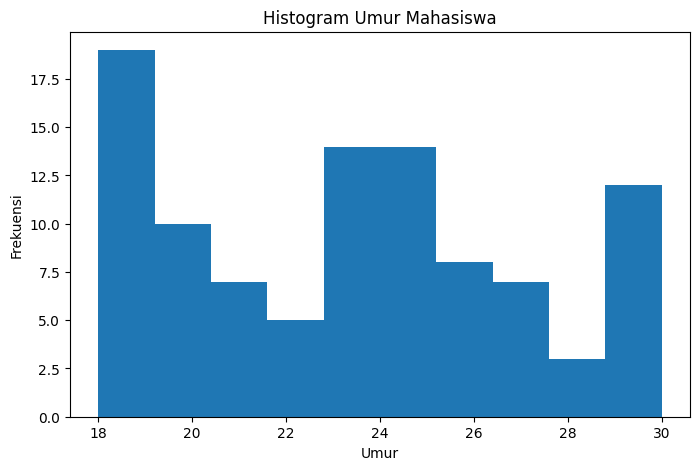

In [15]:
# Buat histogram untuk kolom Umur
plt.figure(figsize=(8,5))
plt.hist(data['Umur'], bins=10)
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.title('Histogram Umur Mahasiswa')
plt.show()

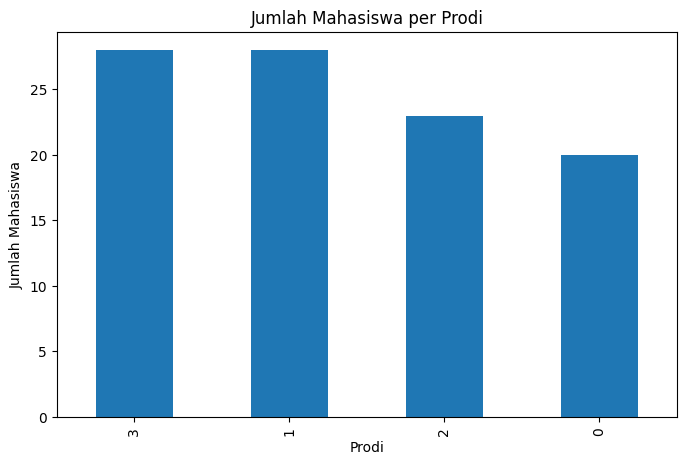

In [16]:
# Buat grafik batang jumlah mahasiswa per Prodi
# Menghitung jumlah mahasiswa per prodi
jumlah_prodi = data['Prodi'].value_counts()
# Membuat grafik batang
plt.figure(figsize=(8,5))
jumlah_prodi.plot(kind='bar')
plt.xlabel('Prodi')
plt.ylabel('Jumlah Mahasiswa')
plt.title('Jumlah Mahasiswa per Prodi')
plt.show()